# will work on California Housing dataset

In [1]:
import pandas as pd


In [2]:
path = r'/Users/raj/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1/housing.csv'
data_set = pd.read_csv(path)


# Initial Exploration

In [3]:
data_set.shape

(20640, 10)

In [4]:
print(data_set.head())
print(data_set.tail())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms

In [5]:
data_set.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [6]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
data_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
data_set.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
(data_set.isnull().mean() * 100).sort_values(ascending=False)

total_bedrooms        1.002907
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [10]:
data_set[data_set['total_bedrooms'].isnull()].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,207.000000,207.000000,207.000000,207.000000,0.0,207.000000,207.000000,207.000000,207.000000
mean,-119.472560,35.497633,29.270531,2562.603865,NaN,1477.772947,510.024155,3.822244,206007.280193
std,2.001424,2.097298,11.964927,1787.269789,NaN,1057.448212,386.120704,1.955595,111638.214545
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.810000,33.970000,19.000000,1307.500000,NaN,781.000000,258.000000,2.564150,128750.000000
50%,-118.490000,34.200000,30.000000,2155.000000,NaN,1217.000000,427.000000,3.411500,175000.000000
75%,-117.985000,37.495000,38.000000,3465.000000,NaN,1889.500000,628.000000,4.615750,267700.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


In [11]:
data_set.duplicated().sum()

np.int64(0)

In [12]:
num_col = data_set.select_dtypes(include="number").columns
print(num_col)
cat_col = data_set.select_dtypes(exclude='number').columns
print(cat_col)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
Index(['ocean_proximity'], dtype='object')


In [13]:
data_set['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

# EDA

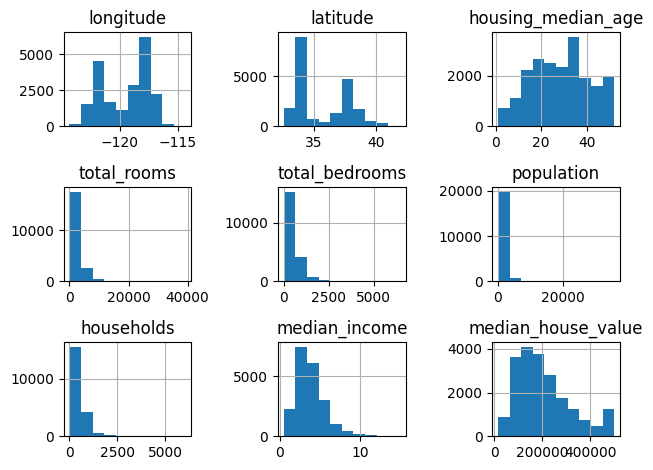

In [14]:
import matplotlib.pyplot as plt
data_set.hist()
plt.tight_layout()
plt.show()

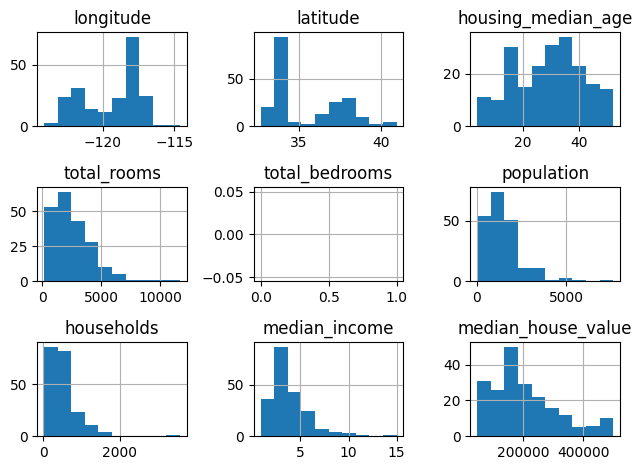

In [15]:
test_data = data_set[data_set['total_bedrooms'].isnull()]
test_data.hist()
plt.tight_layout()
plt.show()

In [16]:
data_set.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


<Axes: xlabel='median_house_value', ylabel='Count'>

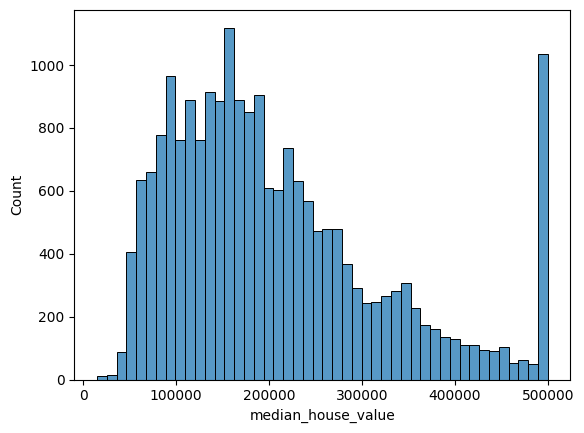

In [17]:
import seaborn as sns
sns.histplot(data_set["median_house_value"])

In [18]:
print(data_set["median_house_value"].max())
(data_set["median_house_value"] == data_set["median_house_value"].max()).sum()

500001.0


np.int64(965)

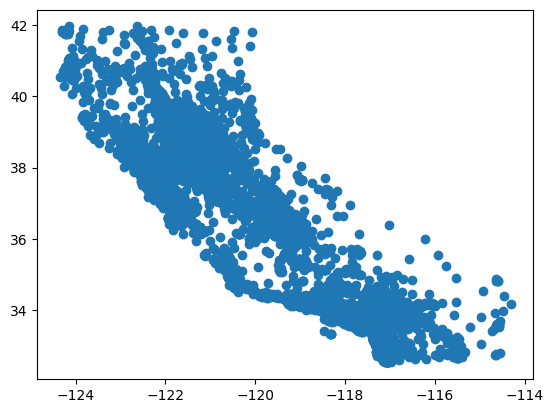

In [19]:
plt.scatter(
    data_set['longitude'],
    data_set['latitude']
)

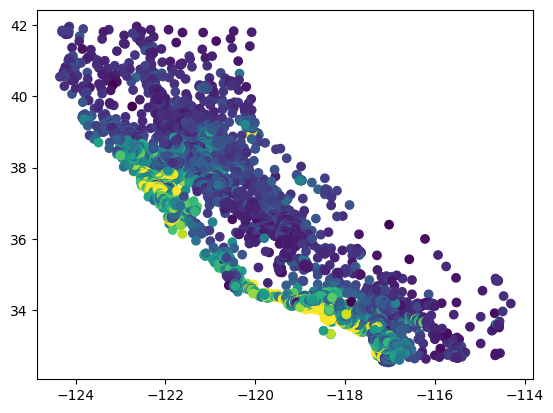

In [20]:
plt.scatter(
    data_set['longitude'],
    data_set['latitude'],
    c=data_set['median_house_value']
)

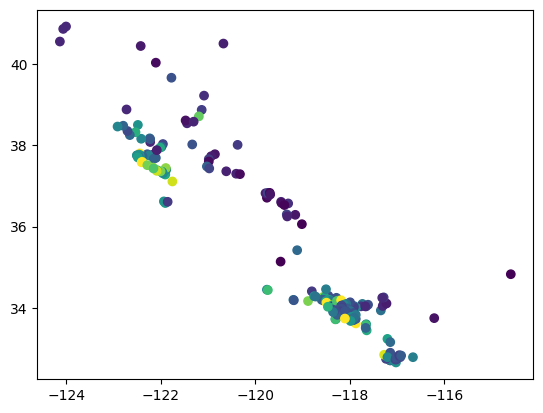

In [21]:
test_data = data_set[data_set['total_bedrooms'].isnull()]
plt.scatter(
    test_data['longitude'],
    test_data['latitude'],
    c=test_data['median_house_value']
)

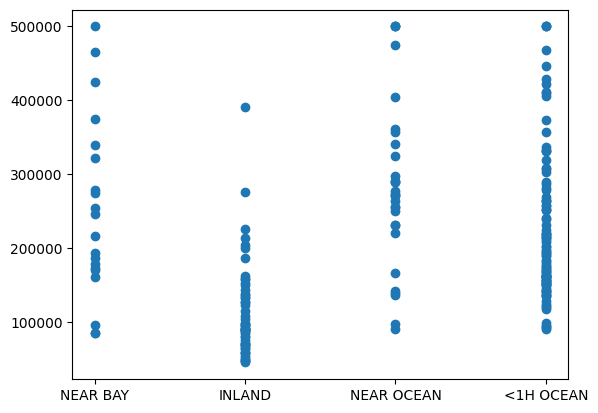

In [22]:
plt.scatter(
    test_data['ocean_proximity'],
    test_data['median_house_value']
)

<Axes: xlabel='median_income', ylabel='median_house_value'>

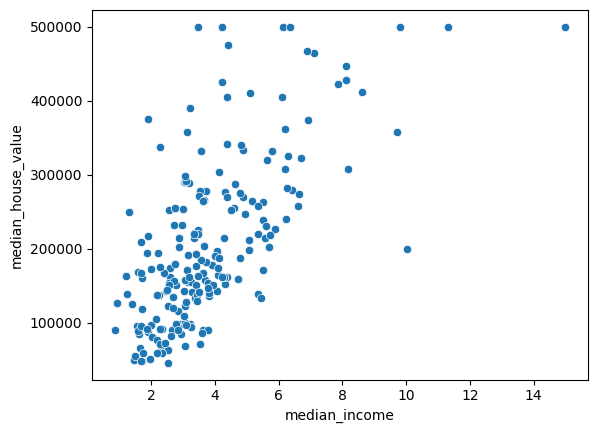

In [23]:
sns.scatterplot(
    x='median_income',
    y='median_house_value',
    data = test_data
)

In [24]:
data_set['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

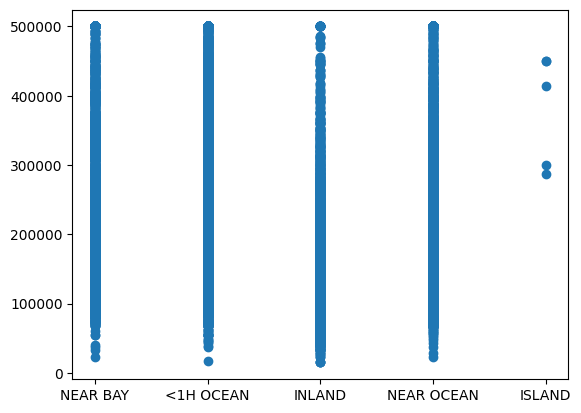

In [25]:
plt.scatter(
    data_set['ocean_proximity'],
    data_set['median_house_value']
)

<Axes: xlabel='ocean_proximity', ylabel='count'>

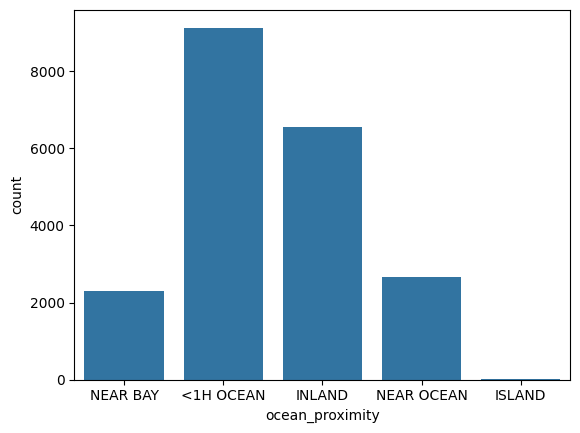

In [26]:
sns.countplot(data=data_set, x='ocean_proximity')

<Axes: xlabel='median_income', ylabel='median_house_value'>

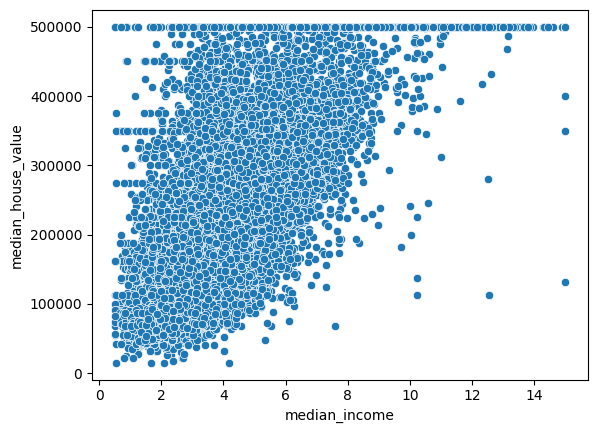

In [27]:
sns.scatterplot(
    x='median_income',
    y='median_house_value',
    data = data_set
)

<Axes: xlabel='housing_median_age', ylabel='median_house_value'>

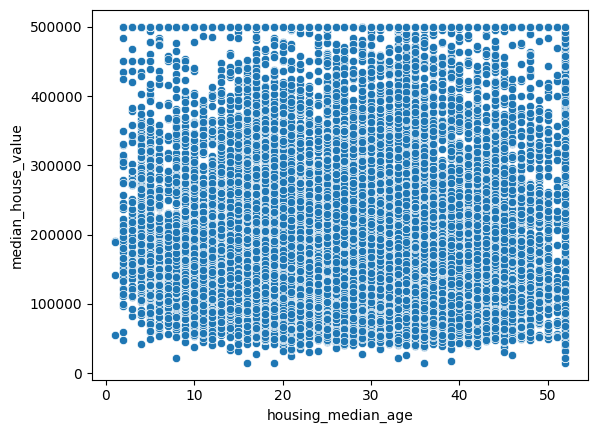

In [28]:
sns.scatterplot(
    x='housing_median_age',
    y='median_house_value',
    data = data_set
)

<Axes: xlabel='median_house_value', ylabel='total_rooms'>

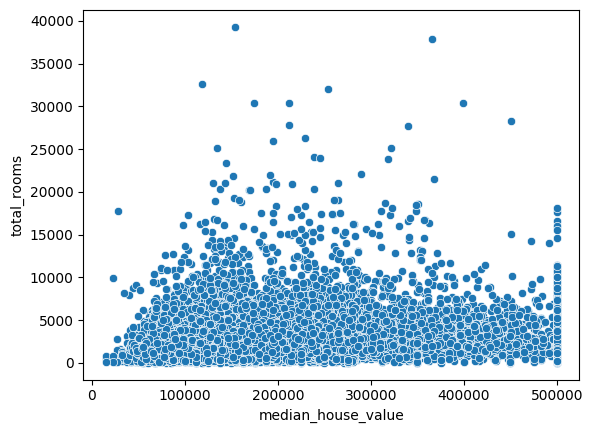

In [29]:
sns.scatterplot(
    x='median_house_value',
    y='total_rooms',
    data=data_set
)

<Axes: xlabel='median_house_value', ylabel='population'>

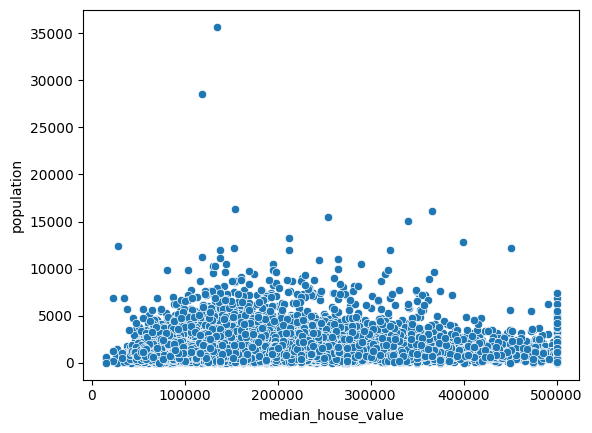

In [30]:
sns.scatterplot(
    x='median_house_value',
    y='population',
    data=data_set
)

<Axes: xlabel='median_house_value', ylabel='households'>

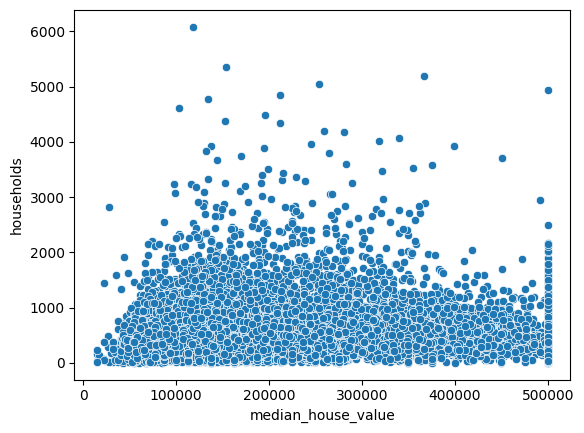

In [31]:
sns.scatterplot(
    y='households',
    x='median_house_value',
    data=data_set
)

# Target value median house values are capped at 500001
# Latitude and Longitude has highly reverseble correlated
# Median Income and Median house value are highly corelated


# Data split

In [32]:
X = data_set.drop('median_house_value', axis=1)
y = data_set['median_house_value']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=42
)

In [34]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(16512, 9)
(16512,)
(4128, 9)
(4128,)


In [35]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['rooms_per_household'] = (
            X['total_rooms'] / 
            X['households']
        )

        X['bedrooms_per_household'] = (
            X['total_bedrooms']/
            X['households']
        )

        X['population_per_household'] = (
            X['population']/
            X["households"]
        )

        # X['bedroom_per_room'] = (
        #     X['total_bedrooms'] /
        #     X['total_rooms']
        # )
        return X

In [36]:
from sklearn.compose import make_column_selector

numeric_features = make_column_selector(dtype_include=['int64', 'float64'])
categorical_features = make_column_selector(dtype_include=['object'])



# Linear Regression

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy='median')),
        ("scalar", StandardScaler())
    ]
)


In [38]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(
    [
        ('encoder', OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [39]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [40]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ("preprocessor", preprocessor),
    ('regressor', LinearRegression())
])

In [41]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(rmse)
print(r2)

69913.9938954297
0.6269892359123017


# Lasso

In [43]:
from sklearn.linear_model import Lasso
lasso_model = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.001, max_iter=10000, random_state=42))
])

In [44]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(lasso_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

/Users/raj/Documents/Corpnce AI/practice/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.957e+12, tolerance: 1.755e+10
  model = cd_fast.enet_coordinate_descent(
/Users/raj/Documents/Corpnce AI/practice/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.972e+12, tolerance: 1.779e+10
  model = cd_fast.enet_coordinate_descent(
/Users/raj/Documents/Corpnce AI/practice/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and ca

In [45]:
print(grid_search.best_params_)

{'regressor__alpha': 1.0}


In [46]:
print(grid_search.best_score_)

0.6495822470128216


In [47]:
best_model = grid_search.best_estimator_

pred = best_model.predict(X_test)

In [48]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(rmse)
print(r2)

69914.6761765349
0.626981955554708


# Ridge

In [49]:
from sklearn.linear_model import Ridge
ridge_p = Pipeline([
    ('feature_engineering', FeatureEngineering()),
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=0.001, max_iter=10000, random_state=42))
])

In [50]:
grid = GridSearchCV(
    estimator = ridge_p,
    param_grid = param_grid,
    scoring = 'r2',
    cv=5,
    n_jobs=-1
)

In [51]:
grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [52]:
print(grid.best_params_)
print(grid.best_score_)

best_ridge_model = grid.best_estimator_
pred = best_ridge_model.predict(X_test)

{'regressor__alpha': 1.0}
0.6495931726962091


In [53]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"rmse = {rmse}")
print(f"r2 score = {r2}")

rmse = 69921.42081395775
r2 score = 0.6269099823166968


# Desision Trees

In [54]:
from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

In [55]:
param_grid = {
    'regressor__max_depth': [3, 5, 10, 15, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator = tree_model, 
    param_grid = param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

In [56]:
dt_grid.fit(X_train, y_train)

print(dt_grid.best_params_)

{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10}


In [57]:
best_model = dt_grid.best_estimator_

pred = best_model.predict(X_test)

In [58]:
def print_rmse_r2(pred, y_test):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"rmse = {rmse}")
    print(f"r2 score = {r2}")

In [59]:
print_rmse_r2(pred, y_test)

rmse = 60358.87259943799
r2 score = 0.7219804227558155


# Random Forest

In [60]:
from sklearn.ensemble import RandomForestRegressor

tree_model = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, 30, 40, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

dt_pipeline  = GridSearchCV(
            estimator= tree_model,
            param_grid = param_grid,
            scoring='r2',
            cv=5,
            n_jobs = -1
)

dt_pipeline.fit(X_train, y_train)

print(dt_pipeline.best_params_)

model = dt_pipeline.best_estimator_

pred = model.predict(X_test)

print_rmse_r2(pred, y_test)

/Users/raj/Documents/Corpnce AI/practice/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'regressor__max_depth': 40, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
rmse = 49719.9802089996
r2 score = 0.8113507711690253


# Feature Importance

In [61]:

rf = model.named_steps['regressor']
importance = rf.feature_importances_

feature_names = (model.named_steps['preprocessor'].get_feature_names_out())


import_df = pd.DataFrame({
    'feature_names': feature_names,
    "importance": importance
})

sorted_imp_df = import_df.sort_values(
    by="importance",
    ascending=False
)

print(sorted_imp_df.head(20))

                      feature_names  importance
7                num__median_income    0.489489
12      cat__ocean_proximity_INLAND    0.141513
10    num__population_per_household    0.120673
0                    num__longitude    0.056905
1                     num__latitude    0.055202
2           num__housing_median_age    0.043501
8          num__rooms_per_household    0.027319
9       num__bedrooms_per_household    0.021410
3                  num__total_rooms    0.011187
4               num__total_bedrooms    0.010199
5                   num__population    0.010104
6                   num__households    0.008811
15  cat__ocean_proximity_NEAR OCEAN    0.001969
11   cat__ocean_proximity_<1H OCEAN    0.000994
14    cat__ocean_proximity_NEAR BAY    0.000697
13      cat__ocean_proximity_ISLAND    0.000027


# Gradient Boosting

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [2, 3, 5],
    'regressor__min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
        estimator = gb_model,
        param_grid = param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(gb_grid.best_params_)

model = gb_grid.best_estimator_

pred = model.predict(X_test)

print(print_rmse_r2(pred, y_test))



{'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
rmse = 46617.84242081227
r2 score = 0.8341568725445524
None


In [63]:
gb = model.named_steps['regressor']
importance = gb.feature_importances_

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature_names': feature_names,
    'importance': importance
})

sorted_imp_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(sorted_imp_df.head(30))


                      feature_names  importance
7                num__median_income    0.516272
12      cat__ocean_proximity_INLAND    0.144808
10    num__population_per_household    0.115553
0                    num__longitude    0.066710
1                     num__latitude    0.064655
2           num__housing_median_age    0.037829
8          num__rooms_per_household    0.018715
9       num__bedrooms_per_household    0.010126
4               num__total_bedrooms    0.005077
3                  num__total_rooms    0.005023
5                   num__population    0.004537
6                   num__households    0.003709
15  cat__ocean_proximity_NEAR OCEAN    0.002923
14    cat__ocean_proximity_NEAR BAY    0.002569
11   cat__ocean_proximity_<1H OCEAN    0.001210
13      cat__ocean_proximity_ISLAND    0.000284


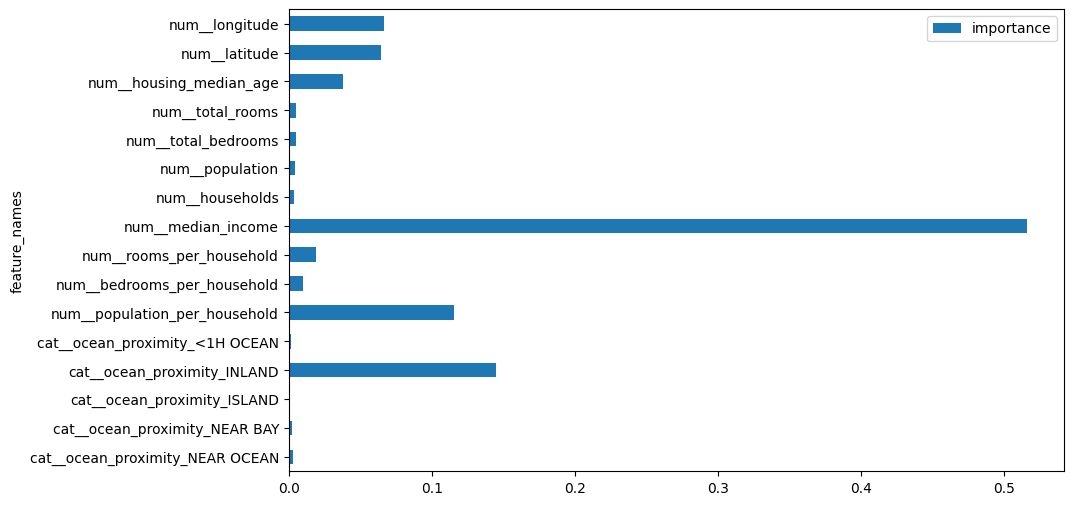

In [64]:
import matplotlib.pyplot as plt

importance_df.plot(
    x='feature_names',
    y='importance',
    kind='barh',
    figsize=(10, 6)
)

plt.gca().invert_yaxis()
plt.show()

# SHapley Additive exPlanations 

In [65]:
import shap

best_model = model
X_train_processed = best_model.named_steps["preprocessor"].transform(
    best_model.named_steps["feature_engineering"].transform(X_train)
)

X_test_processed = best_model.named_steps["preprocessor"].transform(
    best_model.named_steps["feature_engineering"].transform(X_test)
)

gb = best_model.named_steps['regressor']

explainer = shap.Explainer(gb)

shap_values = explainer(X_test_processed)

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

/Users/raj/Documents/Corpnce AI/practice/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


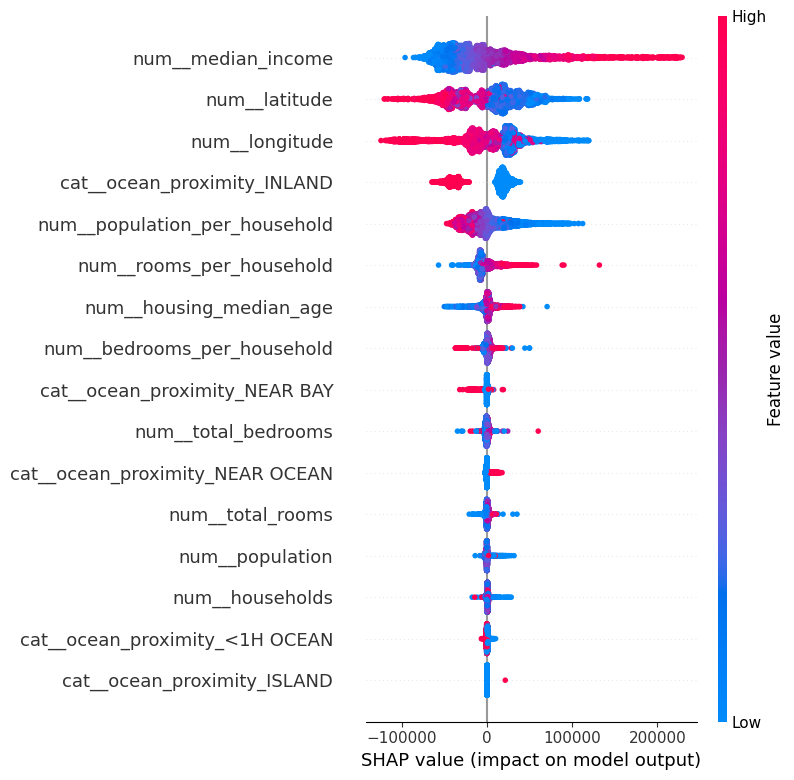

In [66]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

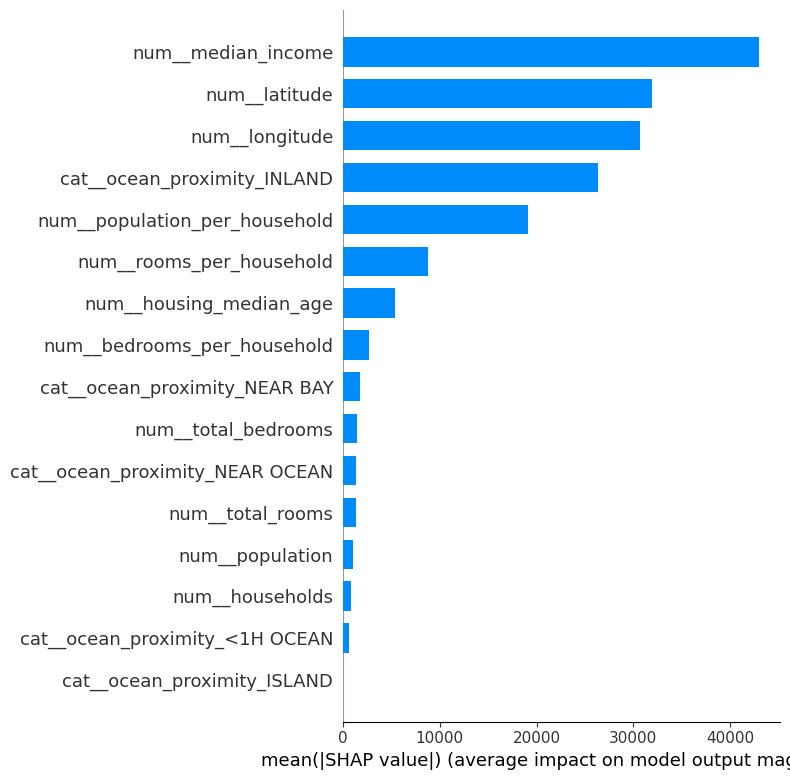

In [67]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [68]:
print(type(shap_values))
print(type(shap_values[0]))

<class 'shap._explanation.Explanation'>
<class 'shap._explanation.Explanation'>


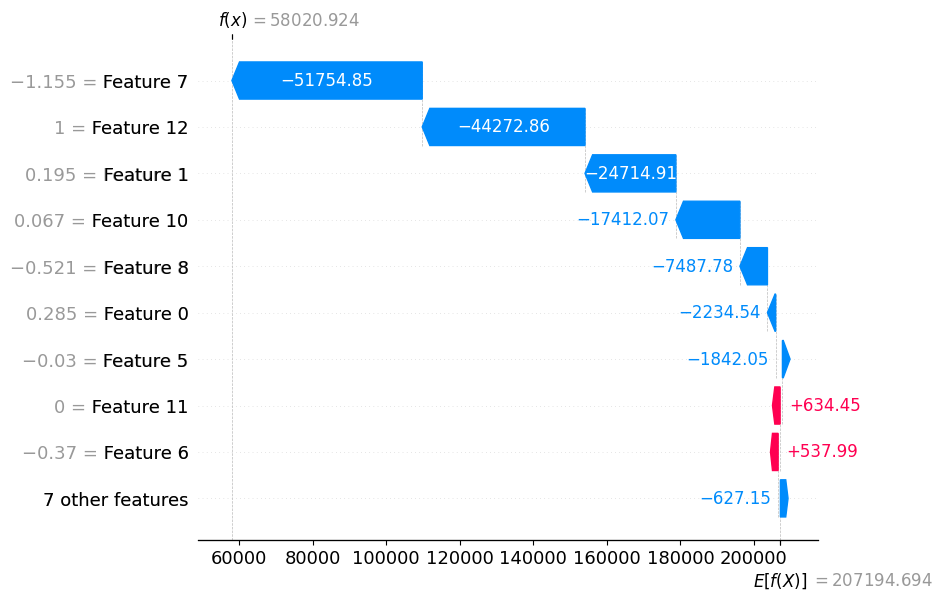

In [69]:
shap.plots.waterfall(shap_values[0])

# XG Boosting

In [71]:
from xgboost import XGBRegressor

gb_model = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [2, 3, 5],
    'regressor__min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
        estimator = gb_model,
        param_grid = param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(gb_grid.best_params_)

model = gb_grid.best_estimator_

pred = model.predict(X_test)

print(print_rmse_r2(pred, y_test))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/raj/Documents/Corpnce AI/practice/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:28:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
 

{'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
rmse = 46026.984329450366
r2 score = 0.8383341901924899
None
